In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master_df = pd.read_csv(
    "../data/processed/stock_features.csv"
)

risk_df = pd.read_csv(
    "../data/processed/risk_summary.csv",
    index_col=0
)

master_df['Date'] = pd.to_datetime(
    master_df['Date']
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10,Rolling_Mean_7,Rolling_Mean_21,Rolling_Std_7,Rolling_Std_21,Target
0,2019-03-13,596.365295,601.986747,587.866665,591.806143,24577591,Reliance,570.531032,554.009042,537.147859,589.305237,559.847534,540.128174,570.531032,554.009042,17.588990,16.027564,593.820007
1,2019-03-14,593.820007,602.871947,591.407614,597.449648,22753310,Reliance,577.101031,555.870228,539.100331,596.365295,562.260071,541.566711,577.101031,555.870228,16.233306,18.233619,585.011658
2,2019-03-15,585.011658,601.455609,580.386082,595.347211,34764353,Reliance,580.695905,557.245571,541.005887,593.820007,560.865723,544.908630,580.695905,557.245571,14.465790,19.311564,597.582458
3,2019-03-18,597.582458,601.079311,588.264944,589.150193,22104063,Reliance,585.741961,559.898234,543.283698,585.011658,577.243347,542.695374,585.741961,559.898234,13.054957,20.858833,609.312439
4,2019-03-19,609.312439,610.839524,594.506199,601.986734,21448030,Reliance,592.662920,562.682640,545.743878,597.582458,589.305237,547.830017,592.662920,562.682640,10.198316,23.343861,608.825378


In [41]:
risk_df.head()

,Annual_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Beta,Volatility_Score,Drawdown_Score,SRI,Risk_Level
SBI,0.233600,0.315618,0.534189,-0.594925,1.253067,10.000000,10.000000,10.000000,High Risk
Maruti,0.168192,0.289660,0.356251,-0.480463,1.004880,6.600070,5.010969,5.964430,Medium Risk
Reliance,0.203808,0.280953,0.494062,-0.450884,1.102506,5.459594,3.721687,4.764431,Medium Risk
Infosys,0.194723,0.274706,0.472224,-0.365498,0.864032,4.641363,0.000000,2.784818,Low Risk
ITC,0.125690,0.239270,0.253646,-0.511127,0.675346,0.000000,6.347524,2.539010,Low Risk


In [42]:
risk_df.columns

Index(['Annual_Return', 'Annualized_Volatility', 'Sharpe_Ratio',
       'Max_Drawdown', 'Beta', 'Volatility_Score', 'Drawdown_Score', 'SRI',
       'Risk_Level'],
      dtype='object')

In [43]:
risk_df = risk_df.reset_index()

risk_df.rename(
    columns={"index":"Company"},
    inplace=True
)

risk_df.head()

,Company,Annual_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Beta,Volatility_Score,Drawdown_Score,SRI,Risk_Level
0,SBI,0.233600,0.315618,0.534189,-0.594925,1.253067,10.000000,10.000000,10.000000,High Risk
1,Maruti,0.168192,0.289660,0.356251,-0.480463,1.004880,6.600070,5.010969,5.964430,Medium Risk
2,Reliance,0.203808,0.280953,0.494062,-0.450884,1.102506,5.459594,3.721687,4.764431,Medium Risk
3,Infosys,0.194723,0.274706,0.472224,-0.365498,0.864032,4.641363,0.000000,2.784818,Low Risk
4,ITC,0.125690,0.239270,0.253646,-0.511127,0.675346,0.000000,6.347524,2.539010,Low Risk


In [44]:
risk_df.columns

Index(['Company', 'Annual_Return', 'Annualized_Volatility', 'Sharpe_Ratio',
       'Max_Drawdown', 'Beta', 'Volatility_Score', 'Drawdown_Score', 'SRI',
       'Risk_Level'],
      dtype='object')

In [12]:
master_df['Daily_Return'] = (
    master_df.groupby('Company')['Close']
    .pct_change()
)

In [14]:
master_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company', 'MA_7',
       'MA_21', 'MA_50', 'Lag_1', 'Lag_5', 'Lag_10', 'Rolling_Mean_7',
       'Rolling_Mean_21', 'Rolling_Std_7', 'Rolling_Std_21', 'Target',
       'Daily_Return'],
      dtype='object')

# Step 2: KPI Cards Data

In [15]:
total_stocks = master_df['Company'].nunique()

print(total_stocks)

6


Average Return

In [16]:
avg_return = (
    risk_df['Annual_Return']
    .mean()
)

avg_return

np.float64(0.1759340703461805)

Average Risk

In [17]:
avg_risk = (
    risk_df['Annualized_Volatility']
    .mean()
)

avg_risk

np.float64(0.27490613810778713)

Best Performing Stock

In [18]:
best_stock = (
    risk_df['Annual_Return']
    .idxmax()
)

best_stock

'SBI'

# Step 3: Stock Price Trend

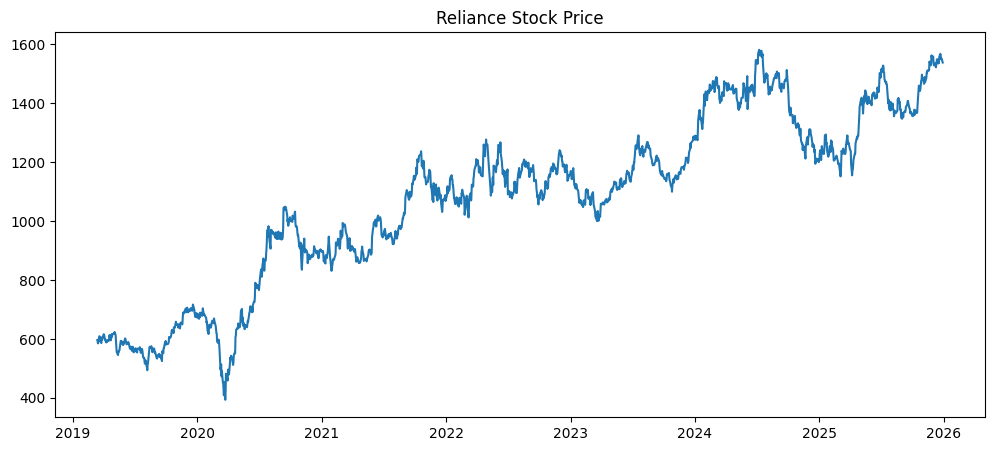

In [19]:
company = "Reliance"

temp = master_df[
    master_df['Company'] == company
]

plt.figure(figsize=(12,5))

plt.plot(
    temp['Date'],
    temp['Close']
)

plt.title(
    f"{company} Stock Price"
)

plt.show()

# Step 4: Return Distribution

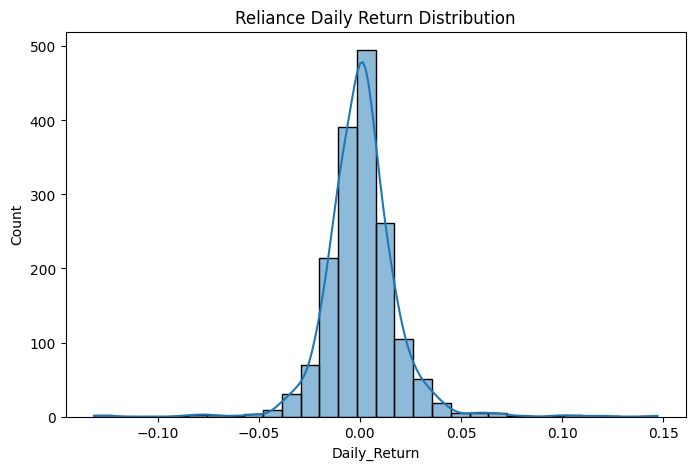

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    temp['Daily_Return'],
    bins=30,
    kde=True
)

plt.title(
    f"{company} Daily Return Distribution"
)

plt.show()

# Step 5: Correlation Heatmap

In [21]:
price_pivot = master_df.pivot(
    index='Date',
    columns='Company',
    values='Close'
)

In [22]:
corr = price_pivot.corr()

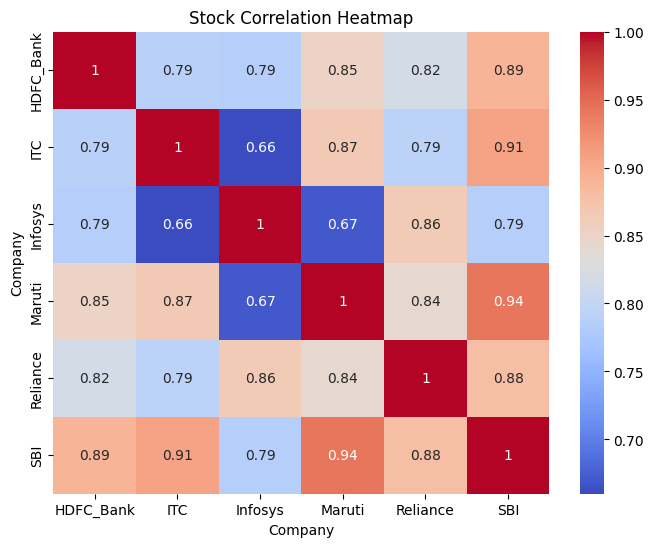

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Stock Correlation Heatmap"
)

plt.show()

# Step 6: Risk vs Return Chart

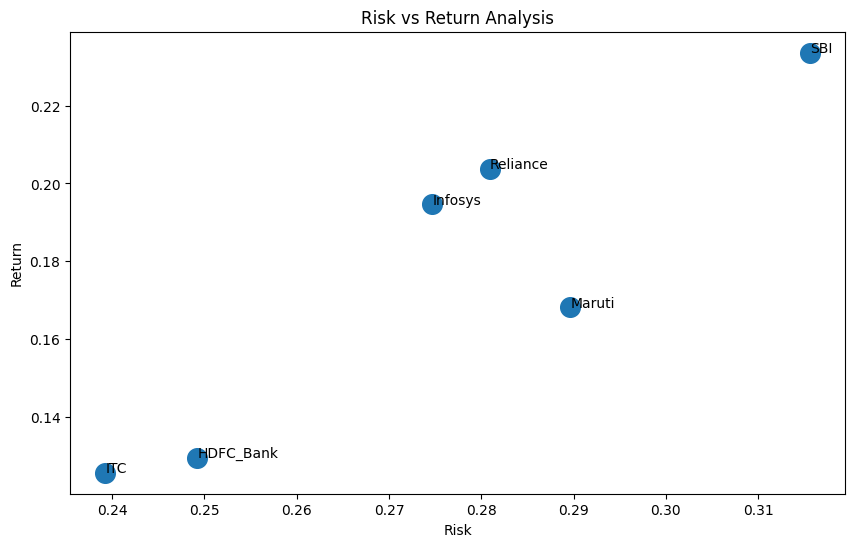

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    risk_df['Annualized_Volatility'],
    risk_df['Annual_Return'],
    s=200
)

for company in risk_df.index:

    plt.annotate(
        company,
        (
            risk_df.loc[
                company,
                'Annualized_Volatility'
            ],
            risk_df.loc[
                company,
                'Annual_Return'
            ]
        )
    )

plt.xlabel("Risk")
plt.ylabel("Return")

plt.title(
    "Risk vs Return Analysis"
)

plt.show()

# Step 7: SRI Ranking

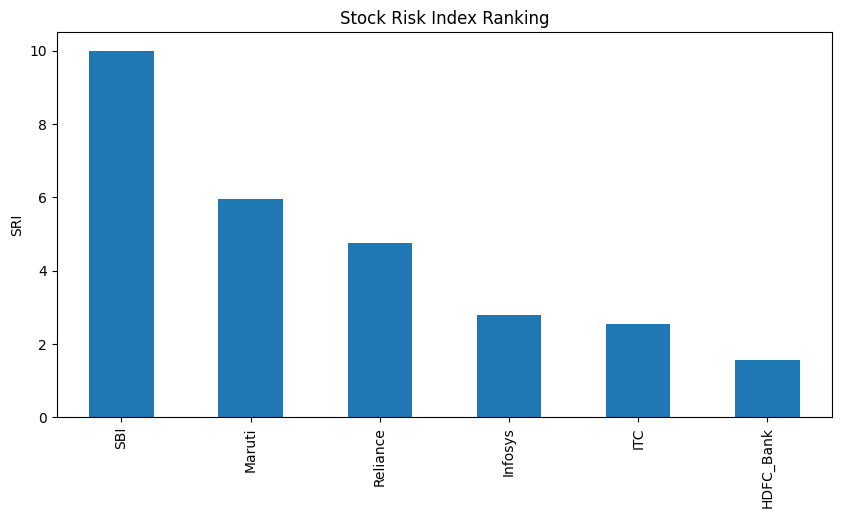

In [26]:
risk_df.sort_values(
    by='SRI',
    ascending=False
)['SRI'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Stock Risk Index Ranking"
)

plt.ylabel("SRI")

plt.show()

# Step 8: Predicted Price Section

In [28]:
import joblib

model = joblib.load(
    "../outputs/models/best_stock_prediction_model.pkl"
)

In [29]:
latest_data = (
    master_df
    .sort_values('Date')
    .tail(1)
)

In [30]:
prediction = model.predict(
    latest_data[[
        'Open',
        'High',
        'Low',
        'Close',
        'Volume',
        'MA_7',
        'MA_21',
        'MA_50',
        'Lag_1',
        'Lag_5',
        'Lag_10',
        'Rolling_Mean_7',
        'Rolling_Mean_21',
        'Rolling_Std_7',
        'Rolling_Std_21'
    ]]
)

prediction

array([949.21762336])

In [31]:
risk_df.to_csv(
    "../data/processed/risk_summary.csv"
)

In [32]:
master_df.to_csv(
    "../data/processed/dashboard_data.csv",
    index=False
)

In [33]:
master_df.to_csv(
    "../outputs/master_df.csv",
    index=False
)

In [45]:
risk_df.to_csv(
    "../outputs/risk_df.csv",
    index=False
)